# Product Category Prediction Based on Product Titles
 **Author: Dragan Aleksic**   
 **Date: 28.09.2026**   

## Introduction

The goal of this project is to develop a machine learning modal that automatically predicts   
the category of a Product based on its title.   

The project uses a real-world product dataset and follows a complete machine learning workflow:

- Data loading and exploration
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Text vectorization
- Training and comparison of multiple machine learning models
- Model evaluation
- Saving the final model
- Interactive product category prediction

## 1. Import Libraries

in this section, we import the Python libraries required for data analysis, visualization and machine learning.

Pandas is used for data manipulation, while matplotlib and seaborn are used for visualization.


In [25]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the dataset

The Dataset contains product information, including product titles and category labels.

The 'Product title' column will be used as the main input feature, while 'Category Lable'    
will be the target variable.

In [26]:
df = pd.read_csv("../data/products.csv")

df.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [27]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 35311
Number of columns: 8


### Conclusion

The dataset was successfully loaded.

It contains 35,311 product records and 8 columns.

## 3. inspect the Dataset

The structure of the Dataset is inspected to understand the available columns and thair data types.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


### Conclusion

The dataset contains product information such as product titles, categories, merchants, views, ratings and listing dates.

The 'Product Title' will be used as the main text feature, while 'Category Label' will be the target variable.

## 4. Clean column Names

Some Column names contain unnecessary leading or trailing spaces.   
These spaces are removed to make the column names consistent and easier to use in the analysis.

In [29]:
df.columns = df.columns.astype(str).str.lower().str.strip()
df.columns = df.columns.str.replace("_", "", regex=False)
print(df.columns)
df.info()

Index(['product id', 'product title', 'merchant id', 'category label',
       'product code', 'numberofviews', 'merchant rating', 'listing date'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product id       35311 non-null  int64  
 1   product title    35139 non-null  str    
 2   merchant id      35311 non-null  int64  
 3   category label   35267 non-null  str    
 4   product code     35216 non-null  str    
 5   numberofviews    35297 non-null  float64
 6   merchant rating  35141 non-null  float64
 7   listing date     35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


## 5. Count missing values per column

Missing values can affect the quality of a machine learning model.

We therefore check how many missing values exist in each column before deciding how to handle them.

In [30]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
product id           0
product title      172
merchant id          0
category label      44
product code        95
numberofviews       14
merchant rating    170
listing date        59
dtype: int64


## Visualize missing data

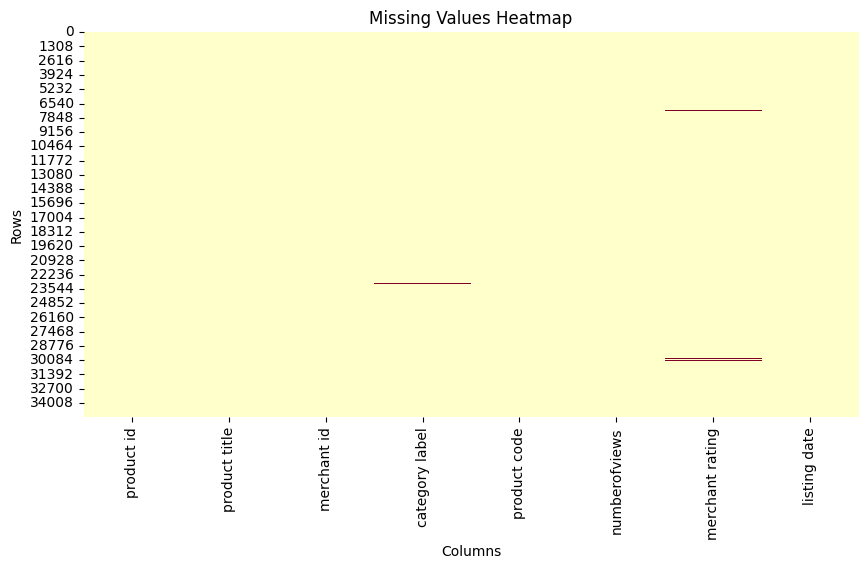

In [31]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Check duplicate product titles

In [32]:
duplicate_titles = df["product title"].duplicated().sum()

print("Number of duplicate product titles:", duplicate_titles)
print("Number of unique product titles:", df["product title"].nunique())

Number of duplicate product titles: 4450
Number of unique product titles: 30860


## Drop all rows with missing values

In [33]:
df = df.dropna()

print("New dataset shape:", df.shape)

print("Missing values per column:")
print(df.isna().sum())

New dataset shape: (34760, 8)
Missing values per column:
product id         0
product title      0
merchant id        0
category label     0
product code       0
numberofviews      0
merchant rating    0
listing date       0
dtype: int64


## 6. Standardize category labels

The dataset contains category labels that differ only by capitalization or singular/plural form.

These values are standardized so that the same category is represented consistently.


In [34]:
print("Categories before stadardization.")
print(sorted(df["category label"].dropna().unique()))

Categories before stadardization.
['CPU', 'CPUs', 'Digital Cameras', 'Dishwashers', 'Freezers', 'Fridge Freezers', 'Fridges', 'Microwaves', 'Mobile Phone', 'Mobile Phones', 'TVs', 'Washing Machines', 'fridge']


In [37]:
category_mapping = {
    "CPU" : "CPUs",
    "fridge" : "Fridges",
    "Mobile Phone" : "Mobile Phones"
}

df["category label"] = df["category label"].replace(category_mapping)

print("Categorys after standadization:")
print(sorted(df["category label"].dropna().unique()))

Categorys after standadization:
['CPUs', 'Digital Cameras', 'Dishwashers', 'Freezers', 'Fridge Freezers', 'Fridges', 'Microwaves', 'Mobile Phones', 'TVs', 'Washing Machines']


## 7. Category distribution

## Category Distribution

In this section, we examine the distribution of products across the different categories.

This gives us an overview of the dataset and helps us identify possible differences in category sizes. A highly imbalanced dataset may affect the performance of the machine learning models.

In [38]:
category_counts = df["category label"].value_counts()

print("Category distribution:")
print(category_counts)

Category distribution:
category label
Fridge Freezers     5424
Mobile Phones       4023
Washing Machines    3971
CPUs                3792
Fridges             3524
TVs                 3502
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
Name: count, dtype: int64


## Plot category distribution

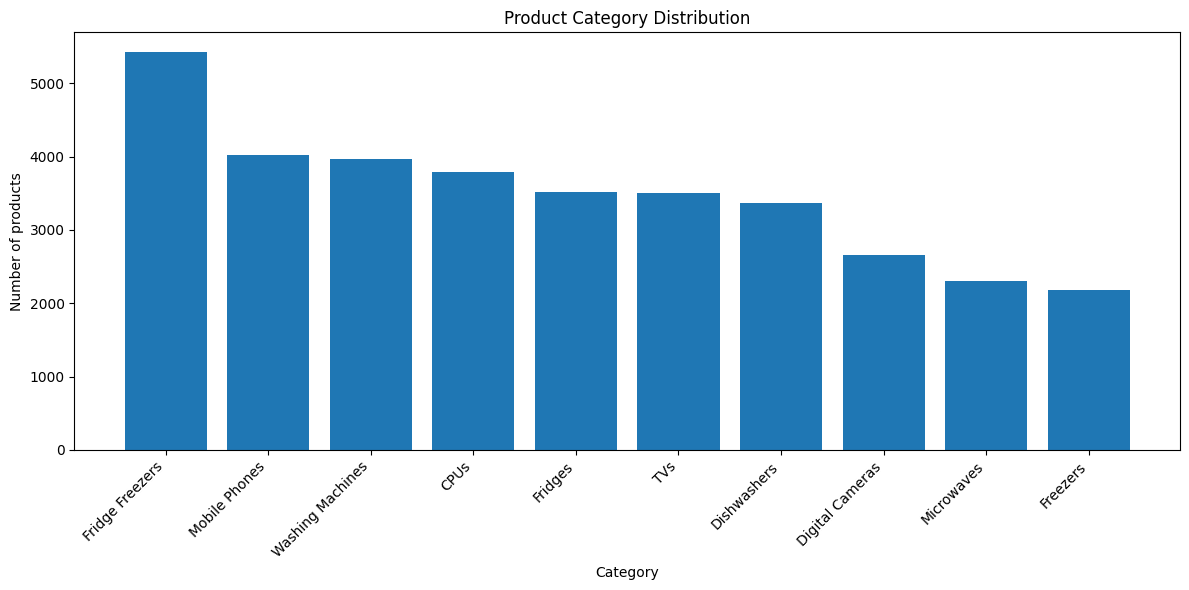

In [39]:
plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Category")
plt.ylabel("Number of products")
plt.title("Product Category Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Remove irrelevant columns

The prediction task is based on the product title.

Columns such as product ID, merchant ID, product code, number of views, merchant rating and listing date are not used as prediction inputs because a new prediction should be possible from the product title alone.

In [40]:
model_data = df[["product title", "category label"]].copy()

print("Columns used for modelling:")
print(model_data.columns.tolist())

model_data.head()

Columns used for modelling:
['product title', 'category label']


,product title,category label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,Mobile Phones


## 9. Featuere engineering 

The task recommends experimenting with additional characteristics of the product title.

The following title-based features are created:

- 'title_length': number of characters
- 'word_count': number of words
- 'digit_count': number of digits
- 'special_char_count': number of special characters
- 'uppercase_count': number of uppercase characters
- 'longest_word_length': length of the longest word

These features are available when a user enters a new product title, so they can also be used during prediction.


In [41]:
model_data["title_length"] = model_data["product title"].str.len()

model_data["word_count"] = (
    model_data["product title"]
    .str.split()
    .str.len()
)

model_data["digit_count"] = (
    model_data["product title"]
    .str.count(r"\d")
)

model_data["special_char_count"] = (
    model_data["product title"]
    .str.count(r"[^a-zA-Z0-9\s]")
)

model_data["uppercase_count"] = (
    model_data["product title"]
    .str.count(r"[A-Z]")
)

model_data["longest_word_length"] = (
    model_data["product title"]
    .str.split()
    .apply(lambda words: max((len(word) for word in words), default=0))
)

model_data.head()


,product title,category label,title_length,word_count,digit_count,special_char_count,uppercase_count,longest_word_length
0,apple iphone 8 plus 64gb silver,Mobile Phones,31,6,3,0,0,6
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones,35,7,3,0,0,9
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,Mobile Phones,70,13,9,2,0,10
3,apple iphone 8 plus 64gb space grey,Mobile Phones,35,7,3,0,0,6
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,Mobile Phones,54,11,6,1,0,8


## 10. Saved cleaned and enineered dataset

After cleaning the data, standardizing the category labels, and creating additional features, the prepared dataset is saved for the next steps of the machine learning workflow.

Saving the processed dataset allows us to reuse the same cleaned data for model training without repeating the previous preprocessing steps.

In [42]:
model_data.to_csv("../data/products_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", model_data.shape)

Cleaned dataset saved successfully.
Shape: (34760, 8)
